In [1]:
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
import pymc as pm
import pymc.sampling.jax as pmjax
import arviz as az
import matplotlib.pyplot as plt

from pytensor.graph.op import Op
import pytensor.tensor as pt
from pytensor.link.jax.dispatch import jax_funcify

jax.config.update("jax_enable_x64", True)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
df = pd.read_csv('/Users/golfgti/Desktop/model_selection_data.csv') # Download the model selection data from the Google Drive
t_meas  = df.iloc[:,1].values
Cb_meas = df.iloc[:,2].values
Ct_meas =  df.iloc[:,3].values
# -------------------------------------------------------------------
# 1) Precompute dense grid + interpolation (once)
# -------------------------------------------------------------------

delta_t = np.concatenate([[t_meas[0]], np.diff(t_meas)])
lamb    = np.log(2) / 109.8 # FDG 109.8 min; FPCIT 792 min
exp_neg = np.exp(-lamb * t_meas)
exp_pos = np.exp( lamb * t_meas)
delta_t_pt = pt.constant(delta_t)
exp_neg_pt = pt.constant(exp_neg)
exp_pos_pt = pt.constant(exp_pos)

max_dt = 0.01  # minutes

t_dense = np.arange(t_meas[0], t_meas[-1] + 1e-8, max_dt)
if t_dense[-1] < t_meas[-1]:
    t_dense = np.concatenate([t_dense, [t_meas[-1]]])

Cb_dense = np.interp(t_dense, t_meas, Cb_meas)
dt_dense = np.concatenate([[t_dense[0]], np.diff(t_dense)])
meas_idx = np.searchsorted(t_dense, t_meas)

# Convert to JAX arrays (float64)
t_dense_jnp   = jnp.array(t_dense,   dtype=jnp.float64)
Cb_dense_jnp  = jnp.array(Cb_dense,  dtype=jnp.float64)
dt_dense_jnp  = jnp.array(dt_dense,  dtype=jnp.float64)
meas_idx_jnp  = jnp.array(meas_idx,  dtype=jnp.int32)

# -------------------------------------------------------------------
# 2) JAX forward solver (pre-computed grid)
# -------------------------------------------------------------------
@jax.jit
def get_curve_jax_2tc_precomp(thetas, Cb_d, dt_d):
    k1, k2, k3, k4, Vb = thetas
    def step(carry, inp):
        Cf, Cp = carry
        Cb_i, dt_i = inp
        dCf = -(k2 + k3) * Cf + k4 * Cp + k1 * Cb_i
        dCp =  k3 * Cf - k4 * Cp
        Cf = Cf + dCf * dt_i
        Cp = Cp + dCp * dt_i
        y_i = Vb * Cb_i + (1 - Vb) * (Cf + Cp)
        return (Cf, Cp), y_i

    (_ , _), y_dense = jax.lax.scan(step,
                                   (0.0, 0.0),
                                   (Cb_d, dt_d))
    return y_dense

@jax.jit
def predict_tac(thetas):
    y_dense = get_curve_jax_2tc_precomp(thetas,
                                        Cb_dense_jnp,
                                        dt_dense_jnp)
    return y_dense[meas_idx_jnp]

# -------------------------------------------------------------------
# 2) JAX forward solver
# -------------------------------------------------------------------

from pytensor.graph.op import Op
import pytensor.tensor as pt
from pytensor.link.jax.dispatch import jax_funcify

class TwoTCPrecompOp(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    @staticmethod
    def do_constant_folding(fgraph, node):
        # Prevent PyTensor from trying to fold this Op into a constant
        return False

    def perform(self, node, inputs, outputs):
        thetas, = inputs
        yj = predict_tac(jax.numpy.array(thetas))
        outputs[0][0] = np.array(yj, dtype=np.float64)

    def grad(self, inputs, output_gradients):
        thetas, = inputs
        gz,      = output_gradients
        _, pullback = jax.vjp(predict_tac, jax.numpy.array(thetas))
        grad_thetas, = pullback(jax.numpy.array(gz))
        return [np.array(grad_thetas, dtype=np.float64)]

@jax_funcify.register(TwoTCPrecompOp)
def jax_funcify_TwoTCPrecompOp(op, **kwargs):
    # Lower the Op to your JAX function during JAX‐trace
    return lambda thetas: predict_tac(thetas)

# then instantiate once:
two_tc_op = TwoTCPrecompOp()

In [3]:
# -------------------------------------------------------------------
# 3) Define priors
# -------------------------------------------------------------------
def brain_priors():
    k1 = pm.LogNormal("k1", mu=-0.4049652330665133, sigma=0.3393198089150609)
    k2 = pm.LogNormal("k2", mu=-0.3638434334173450, sigma=0.2479388785866902)
    k3 = pm.LogNormal("k3", mu=-5.8091429903140280, sigma=0.3245928459745013)
    k4 = pm.LogNormal("k4", mu=-2.9957322735539910, sigma=0.1980422004353651)
    Vb = pm.LogNormal("Vb", mu=-6.9077552789821370, sigma=1.2686362411795196)
    return pt.stack([k1, k2, k3, k4, Vb], axis=0)

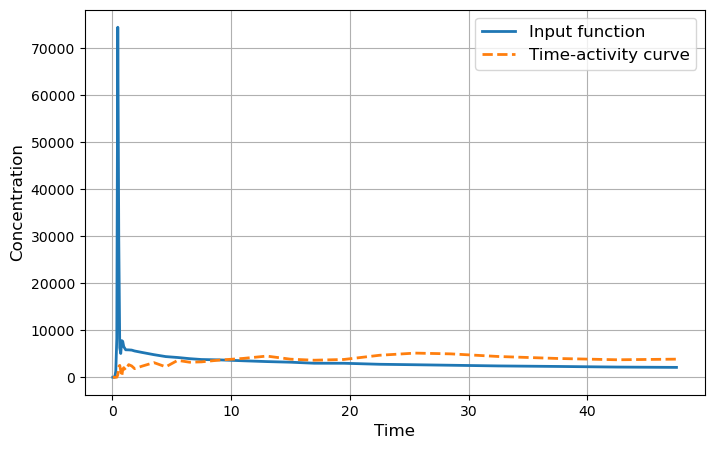

In [8]:
#-------------------------------------------------------------------
# 4) Visualise data
# -------------------------------------------------------------------
plt.figure(figsize=(8, 5))

# Plot both curves
plt.plot(t_meas, Cb_meas, label='Input function', linewidth=2)
plt.plot(t_meas, Ct_meas, label='Time-activity curve', linewidth=2, linestyle='--')

# Add labels, title, and legend
plt.xlabel('Time', fontsize=12)
plt.ylabel('Concentration', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Show figure
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

array([[<Axes: title={'center': 'Vb'}>, <Axes: title={'center': 'Vb'}>],
       [<Axes: title={'center': 'k1'}>, <Axes: title={'center': 'k1'}>],
       [<Axes: title={'center': 'k2'}>, <Axes: title={'center': 'k2'}>],
       [<Axes: title={'center': 'k3'}>, <Axes: title={'center': 'k3'}>],
       [<Axes: title={'center': 'k4'}>, <Axes: title={'center': 'k4'}>],
       [<Axes: title={'center': 'l1'}>, <Axes: title={'center': 'l1'}>]],
      dtype=object)

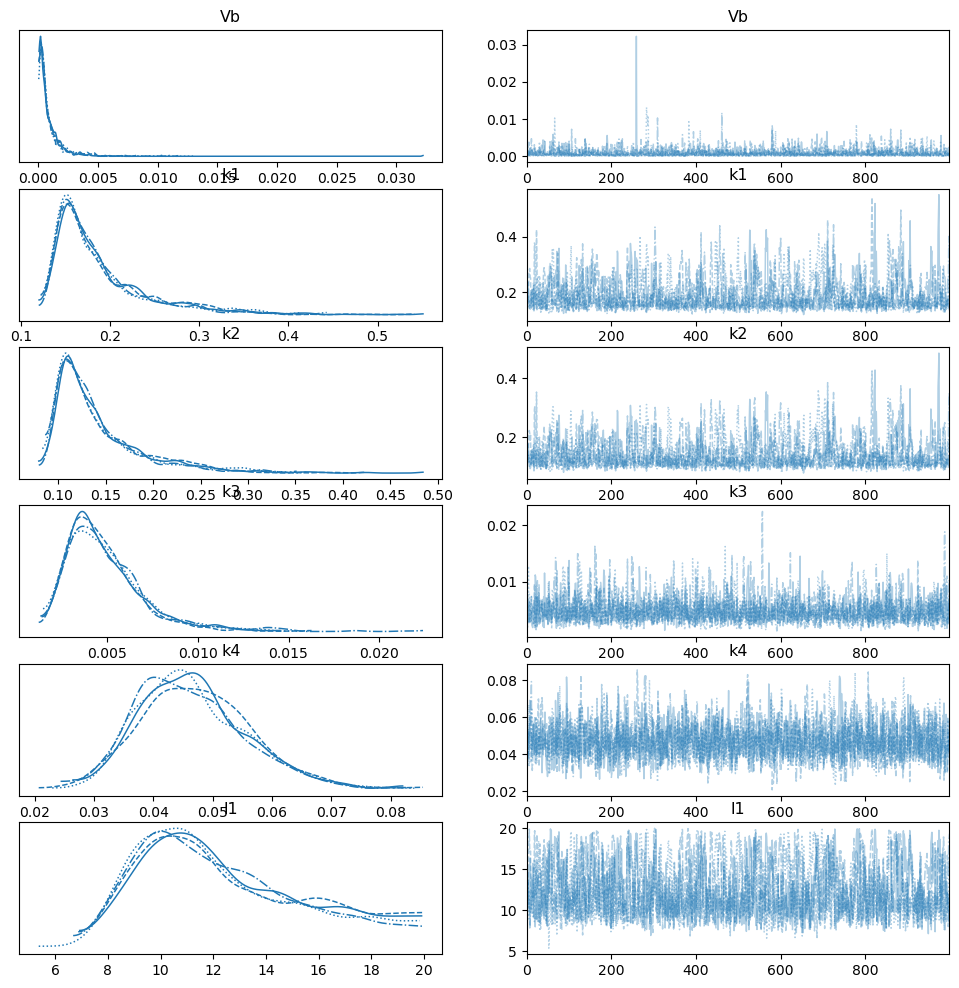

In [4]:
#-------------------------------------------------------------------
# 3) Build & sample the PyMC model
# -------------------------------------------------------------------
with pm.Model() as model:
    thetas = brain_priors()
    
    l1  = pm.Uniform("l1",  5, 20) # noise level

    Ct_pred = two_tc_op(thetas)
    Ct_pred = pt.maximum(Ct_pred, 1e-8)

    sigma_t = pt.sqrt(Ct_pred * exp_neg_pt / delta_t_pt) * exp_pos_pt
    sigma   = l1 * sigma_t
    
    pm.Normal("obs", mu=Ct_pred, sigma=sigma, observed=Ct_meas)

    trace = pmjax.sample_numpyro_nuts(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        compute_convergence_checks=True
    )

az.plot_trace(trace)
# plt.gcf().savefig("trace_diagnostics.png", dpi=300, bbox_inches="tight")